In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HuggingFace_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is not set in the environment variables.")
if not HuggingFace_API_KEY:    
    raise ValueError("HuggingFace_API_KEY is not set in the environment variables.")


In [2]:
##BUILD INDEX

from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_classic.document_loaders import WebBaseLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.vectorstores import FAISS
from langchain_community.tools import TavilySearchResults

# Set Embeddings

embeddings = HuggingFaceEmbeddings()   
embeddings

/opt/anaconda3/envs/genai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-mpnet-base-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [3]:
## WEB URLS
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/add-memory",
    "https://docs.langchain.com/oss/python/langgraph/use-subgraphs"
]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)

#LOAD

docs = [WebBaseLoader(url).load() for url in urls]

docs_list = [item for sublist in docs for item in sublist]

#SPLIT

docs_split = text_splitter.create_documents([doc.page_content for doc in docs_list])

docs_split[0]

Document(metadata={}, page_content='LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCore benefitsLangGraph ecosystemAcknowledgementsLangGraph overviewCopy pageGain control with LangGraph to design agents that reliably handle complex tasksCopy pageTrusted by companies shaping the future of agents— including Klarna, Uber, 

In [4]:
#VECTOR STORE
vectorstore = FAISS.from_documents(docs_split, embeddings)

retriever = vectorstore.as_retriever()

In [5]:
## Retrieval Grader

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

#DATA MODEL
class GradeDocuments(BaseModel):
    """Whether the retrieved documents are relevant to the question."""
    relevance: str = Field(description="Whether the retrieved documents are relevant to the question. 'yes or no' answer only.")

#LLM
model = ChatGroq(model="qwen/qwen3-32b", api_key=GROQ_API_KEY)

#STRUCTURED OUTPUT
model_with_structured_output = model.with_structured_output(GradeDocuments)


In [6]:

#PROMPT
system = """You are a helpful assistant for grading the relevance of retrieved documents to a question.
You will be given a question and a list of retrieved documents.
Your task is to determine whether the retrieved documents are relevant to the question.
Answer 'yes' if the retrieved documents are relevant to the question, and 'no' if they are not relevant.
"""

grade_prompt = ChatPromptTemplate.from_messages(
    [("system", system),
     ("human", "Question: {question}\n\n Retrieved Documents:\n {retrieved_docs}"),
    ])       

In [10]:
#CHAIN

retrieval_grader_chain = grade_prompt | model_with_structured_output

question = "What is LangGraph?"

docs = retriever.invoke(question)

docs_text = "\n".join([doc.page_content for doc in docs])

print(retrieval_grader_chain.invoke({'question': question, 'retrieved_docs': docs_text}))

relevance='yes'


In [ ]:
#GENERATE RESPONSE
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

#PROMPT
prompt = hub.pull('rlm/rag-prompt')

#LLM
model = ChatGroq(model="qwen/qwen3-32b", api_key=GROQ_API_KEY)

#POST PROCESSING
def format_retrieved_docs(retrieved_docs):
    formatted_docs = ""
    for i, doc in enumerate(retrieved_docs):
        formatted_docs += f"Document {i+1}:\n{doc.page_content}\n\n"
    return formatted_docs

#CHAIN
rag_chain = prompt | model | StrOutputParser()

#RUN

generation = rag_chain.invoke({'question': question, 'context': format_retrieved_docs(docs)})

In [12]:
generation

'<think>\nOkay, the user is asking, "What is LangGraph?" Let me check the provided documents to form an answer.\n\nFrom Document 1, I see that LangGraph is inspired by Pregel and Apache Beam, and it\'s built by LangChain Inc. It can be used without LangChain. Document 2 mentions it\'s low-level and focused on agent orchestration, with features like durable execution and streaming. Document 4 adds that it\'s a framework for building and managing long-running, stateful agents, trusted by companies like Uber and J.P. Morgan. \n\nPutting this together, LangGraph is a framework for orchestrating agents, designed to handle complex tasks with features like durability and streaming. It\'s built by LangChain but doesn\'t require LangChain to use. I should mention the key points: low-level, agent orchestration, key features, and maybe the inspiration sources. Need to keep it concise, under three sentences. Let me make sure not to include any installation details or specific examples unless neces

In [13]:
## QUESTION REWRITER

llm = ChatGroq(model="qwen/qwen3-32b", api_key=GROQ_API_KEY)

#PROMPT
system = """You are a helpful assistant for rewriting questions to be more effective for retrieval.
You will be given a question and a list of retrieved documents.
Your task is to rewrite the question to be more effective for retrieval based on the retrieved documents.
"""

re_write_prompt = ChatPromptTemplate.from_messages(
    [("system", system),
     ("human", "Question: {question}\n\n Retrieved Documents:\n {retrieved_docs}"),
    ]) 

question_rewriter_chain = re_write_prompt | llm | StrOutputParser()

new_question = question_rewriter_chain.invoke({'question': question, 'retrieved_docs': docs_text})

new_question

'<think>\nOkay, let me try to work through this. The user is asking "What is LangGraph?" and they provided some retrieved documents. My job is to rewrite the question to make it more effective for retrieval based on those documents.\n\nFirst, I need to understand the original question. The user wants a definition or explanation of LangGraph. The retrieved documents mention that LangGraph is inspired by Pregel and Apache Beam, built by LangChain Inc, and is a low-level framework for agent orchestration. It\'s used for durable execution, streaming, and human-in-the-loop scenarios. It can be used with or without LangChain.\n\nNow, the original question is straightforward, but maybe the documents have more specific information that the user wants to highlight. The documents talk about LangGraph being a low-level orchestration framework for building stateful agents, supporting features like durable execution, streaming, and subgraphs. They also mention that it\'s separate from LangChain but

In [14]:
## SEARCH TOOL
from langchain_community.tools import TavilySearchResults

web_search_tool = TavilySearchResults(api_key=TAVILY_API_KEY,k=3)

from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """Represents the state of the graph, including the question and retrieved documents.
    
    Attributes:
        question (str): The original question posed by the user.
        generation (str): The generated response based on the retrieved documents.
        web_search (str): The results from the web search tool.
        retrieved_docs (List[str]): A list of retrieved documents relevant to the question."""

    question: str
    generation: str
    web_search: str
    retrieved_docs: List[str]


from langchain_classic.schema import Document

def retrieve_documents(state):
    """Retrieves documents based on the question in the graph state.
    
    Args:
        state (GraphState): The current state of the graph, containing the question and other relevant information.
    
    Returns:
        List[Document]: A list of retrieved documents relevant to the question."""
    print("--- RETRIEVING DOCUMENTS ---")
    question = state['question']
    retrieved_docs = retriever.invoke(question)
    return {
        "retrieved_docs": retrieved_docs,
        "question": question
    }

def generate_response(state):
    """Generates a response based on the question and retrieved documents in the graph state.
    
    Args:
        state (GraphState): The current state of the graph, containing the question, retrieved documents, and other relevant information.

    Returns:
        str: The generated response based on the question and retrieved documents."""
    print("--- GENERATING RESPONSE ---")
    question = state['question']
    retrieved_docs = state['retrieved_docs']
    context = format_retrieved_docs(retrieved_docs)
    generation = rag_chain.invoke({'question': question, 'context': context})
    return {
        "generation": generation,
        "question": question,
        "retrieved_docs": retrieved_docs
    }

def grade_documents(state):
    """Grades the relevance of the retrieved documents to the question in the graph state.
    
    Args:
        state (GraphState): The current state of the graph, containing the question, retrieved documents, and other relevant information.
    
    Returns:
        List[bool]: A list of boolean values indicating whether each retrieved document is relevant to the question.
    """
    print("--- CHECKING DOCUMENTS RELEVANCE TO QUESTION ---")
    question = state['question']
    retrieved_docs = state['retrieved_docs']
    web_search = 'no'
    filtered_docs = []  
    #score each retrieved document for relevance to the question
    for doc in retrieved_docs:
        score = retrieval_grader_chain.invoke({'question': question, 'retrieved_docs': doc.page_content})
        print(f"Document: {doc.page_content[:100]}... Relevance Score: {score.relevance}")
        grade = score.relevance.lower()
        if grade == 'yes':
            print("Document is relevant to the question.")
            filtered_docs.append(doc)
        else:
            print("Document is not relevant to the question.")
            web_search = 'yes'
            continue
    return {
        "retrieved_docs": filtered_docs,
        "question": question,
        "web_search": web_search
    }

def perform_web_search(state):
    """Performs a web search using the web search tool based on the question in the graph state.
    
    Args:
        state (GraphState): The current state of the graph, containing the question and other relevant information.
    
    Returns:
        str: The results from the web search tool."""
    print("--- PERFORMING WEB SEARCH ---")
    question = state['question']
    documents = state['retrieved_docs']

    #WEB SEARCH ONLY IF DOCUMENTS ARE NOT RELEVANT
    docs = web_search_tool.invoke(question) if state['web_search'] == 'yes' else documents
    web_search_results = "\n".join(d['content'] for d in docs)
    web_search_results = Document(page_content=web_search_results)
    documents.append(web_search_results)
    return {
        "retrieved_docs": documents,
        "question": question
    }

def transform_question(state):
    """Transforms the question in the graph state to be more effective for retrieval.
    
    Args:
        state (GraphState): The current state of the graph, containing the question and other relevant information.
    
    Returns:
        str: The transformed question that is more effective for retrieval."""
    print("--- TRANSFORMING QUESTION ---")
    question = state['question']
    retrieved_docs = state['retrieved_docs']
    docs_text = "\n".join([doc.page_content for doc in retrieved_docs])
    new_question = question_rewriter_chain.invoke({'question': question, 'retrieved_docs': docs_text})
    return {
        "question": new_question,
        "retrieved_docs": retrieved_docs
    }

/var/folders/34/r3qv8fk11c5f4nqq25fzx7640000gn/T/ipykernel_8796/2798591427.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(api_key=TAVILY_API_KEY,k=3)


In [15]:
###EDGES

def decide_to_generate(state):
    """Decides whether to generate a response based on the relevance of the retrieved documents in the graph state.
    
    Args:
        state (GraphState): The current state of the graph, containing the question, retrieved documents, and other relevant information.

    Returns:
        bool: True if the retrieved documents are relevant enough to generate a response, False otherwise.
    """
    print("--- DECIDING TO GENERATE RESPONSE ---")
    question = state['question']
    retrieved_docs = state['retrieved_docs']
    web_search = state['web_search']
    if web_search == 'yes':
        print("Web search was performed, proceeding to generate response.")
        return "transform_question"
    else:
        print("Retrieved documents are relevant, proceeding to generate response.")
        return "generate_response"

In [16]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(GraphState)

#DEFINE NODES
workflow.add_node("retrieve_documents", retrieve_documents)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("perform_web_search", perform_web_search)
workflow.add_node("transform_question", transform_question)
workflow.add_node("generate_response", generate_response)

#DEFINE EDGES
workflow.add_edge(START, "retrieve_documents")
workflow.add_edge("retrieve_documents", "grade_documents")
workflow.add_conditional_edges("grade_documents", decide_to_generate,
                               {"generate_response": "generate_response",
                                "transform_question": "transform_question"
                               })
workflow.add_edge("transform_question", "perform_web_search")
workflow.add_edge("perform_web_search", "generate_response")
workflow.add_edge("generate_response", END)

#COMPILE GRAPH
app = workflow.compile()

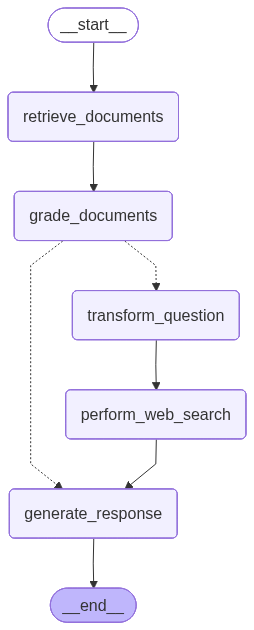

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [18]:
app.invoke({"question": "Who is the Prime Minister of the United Kingdom?"})

--- RETRIEVING DOCUMENTS ---
--- CHECKING DOCUMENTS RELEVANCE TO QUESTION ---
Document: @tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    return f"Info about ... Relevance Score: no
Document is not relevant to the question.
Document: for event in app.stream(
    {"messages": [{"role": "user", "content": "what's my name?"}]},
    con... Relevance Score: no
Document is not relevant to the question.
Document: model = init_chat_model(model="claude-haiku-4-5-20251001")

@dataclass
class Context:
    user_id: s... Relevance Score: no
Document is not relevant to the question.
Document: @tool
def fruit_info(fruit_name: str) -> str:
    """Look up fruit info."""
    return f"Info about ... Relevance Score: no
Document is not relevant to the question.
--- DECIDING TO GENERATE RESPONSE ---
Web search was performed, proceeding to generate response.
--- TRANSFORMING QUESTION ---
--- PERFORMING WEB SEARCH ---


TypeError: string indices must be integers